In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
%matplotlib widget

In [2]:
# Gaussian Wave Function

def psi(x,sig):
    return (1/(2*np.pi*sig**2))**0.25*np.exp(-x**2/(4*sig**2))

def phi(p,sig):
    return (2*sig**2/np.pi)**0.25*np.exp(-sig**2*p**2)


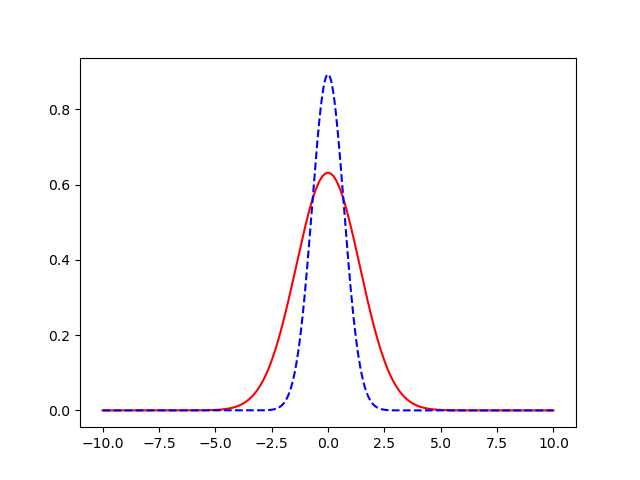

In [3]:
xf = np.linspace(-10,10,1000)
plt.plot(xf, psi(xf,1),"r-")
plt.plot(xf, phi(xf,1),"b--")

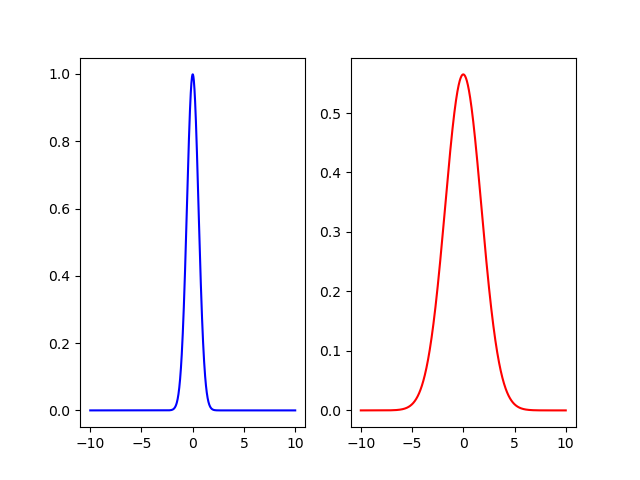

In [4]:
fig, axes = plt.subplots(nrows=1, ncols=2)
axes = axes.flatten()
axes[0].plot(xf, psi(xf,0.4),"b-")
axes[1].plot(xf, phi(xf,0.4),"r-")

In [5]:
total_frames=200
def sig(i):  
    i = i%total_frames
    half = total_frames / 2
    a = 0.2
    b = 1/(2*a)
    if (i<half):    
        return a + (b-a)*i/half
    else:
        return b + (a-b)*(i-half)/half


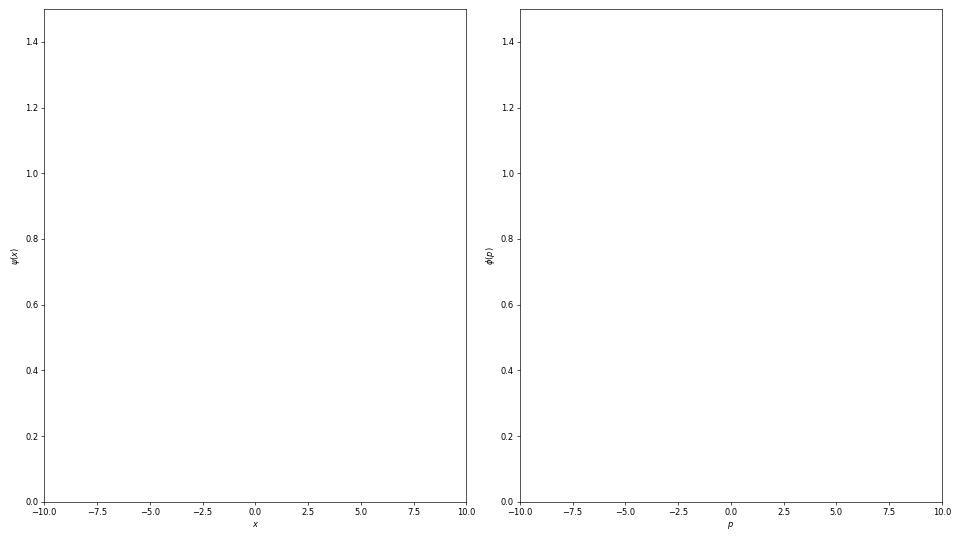

In [9]:
# animation parameters
tstep = 1
fps = 20
frame_ms = int(1000 / fps)
second_tau = fps * tstep

# setup the figures
fig, axes = plt.subplots(1, 2, figsize=(16, 9), dpi=1920/32)
xf = np.linspace(-10, 10, 1000)
la, = axes[0].plot([], [], "b-")
lb, = axes[1].plot([], [], "r-")

axes[0].set_xlim(-10, 10)
axes[1].set_xlim(-10, 10)
axes[0].set_ylim(0, 1.5)
axes[1].set_ylim(0, 1.5)

axes[0].set_xlabel("$x$")
axes[0].set_ylabel("$\\psi(x)$")
axes[1].set_xlabel("$p$")
axes[1].set_ylabel("$\\phi(p)$")

# initialization of plots:
def init():
    la.set_data([], [])
    lb.set_data([], [])
    return la, lb

# update plots once per frame:
def animate(i):
    s = sig(i)
    la.set_data(xf, psi(xf, s))
    lb.set_data(xf, phi(xf, s))
    return la, lb

#run the animation:
anim = FuncAnimation(
    fig,
    animate,
    frames=200,
    init_func=init,
    interval=frame_ms,
    blit=False,
    repeat=True,
)

plt.tight_layout()
plt.show()